<a href="https://colab.research.google.com/github/mp-codez/probability-statistics-experiments/blob/solution/task_40_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sheet_id = "1dAc3E4U-gBzihJ6HLM2kYVDAqQthdReg20zwwaplTW8"
file_url= f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

In [4]:
insurance = pd.read_csv(file_url)

In [5]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   object 
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   object 
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   object 
 9   region         1337 non-null   object 
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 115.3+ KB


# **Q-1: What is the probability distribution of age in the insurance dataset?**

#### Solution :
To find the probability distribution of age, we can plot a histogram and fit a probability density function (PDF) to it using Kernel Density Estimation (KDE) as follows:

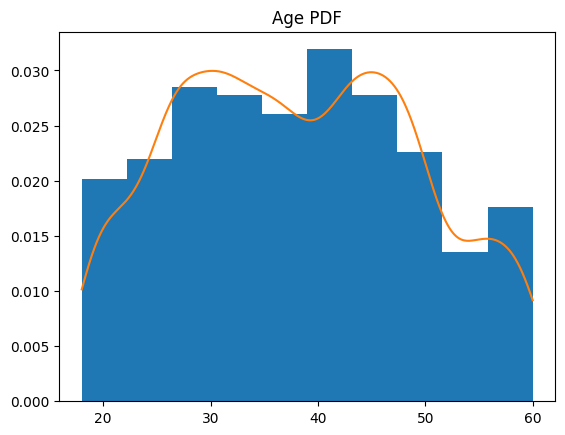

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.neighbors import KernelDensity

#Load the Data
data = insurance

#plot histogram of age
plt.hist(data['age'], density=True)

# Convert age data into numpy 2D array
sample_data = data['age'].dropna().to_numpy().reshape(-1, 1)

# Create KDE
model = KernelDensity(bandwidth=2, kernel='gaussian')

# Fit KDE to age data
kde = model.fit(sample_data)

# Evaluate PDF over age range
age_range = np.linspace(data['age'].min(), data['age'].max(), 1000)
pdf = np.exp(kde.score_samples(age_range.reshape(-1, 1)))


# Plot PDF
plt.plot(age_range, pdf)
plt.title('Age PDF')
plt.show()

### Q-2: What is the probability of a patient having a BMI greater than 30?

####*Solution*

#### we can calculate the probability of a patient having a BMI greater than 30 by counting the number of patients with a BMI greater than 30 and dividing by the total number of patients in the dataset.

In [41]:
bmi_greater_than_30 = insurance[insurance['bmi'] > 30]
probability_bmi_greater_than_30 = len(bmi_greater_than_30)/len(insurance)
print(probability_bmi_greater_than_30)

0.5216417910447761


### Q-3: Plot distribution plot of claim for Smoker and non smoker. What changes you see in the plot?

<Axes: xlabel='claim', ylabel='Count'>

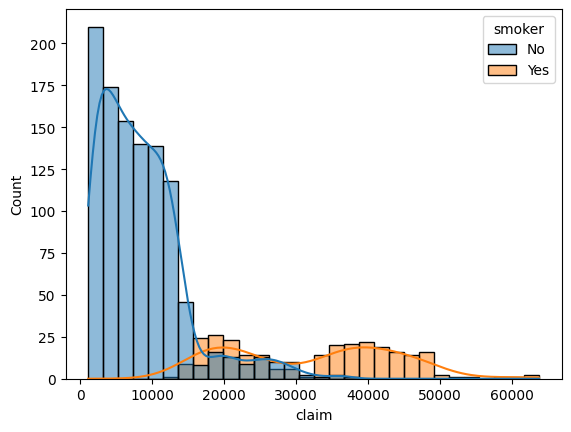

In [63]:
sns.histplot(insurance, x='claim', kde=True, hue='smoker')

* Claim for non smoker is lesser than smokers.
* Most Claims of non-smokers lies in range 0-15000, and Smoker's claims are greater than 15000

### Q-4: Plot the 2D probability density plot of claim and age in the insurance dataset?

<Axes: xlabel='age', ylabel='claim'>

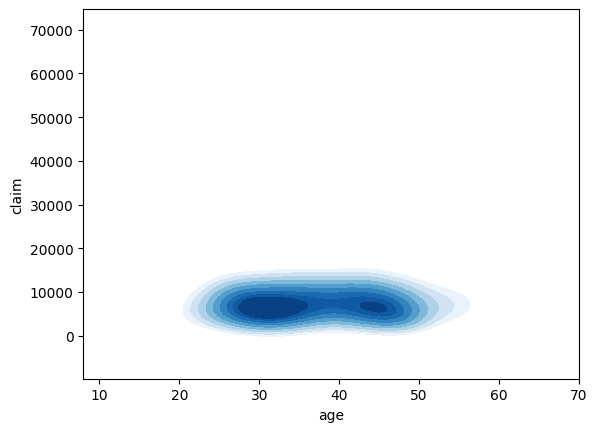

In [64]:
sns.kdeplot(x=insurance['age'], y=insurance['claim'], cmap='Blues', thresh=0.5, fill=True)

<Axes: xlabel='claim', ylabel='Density'>

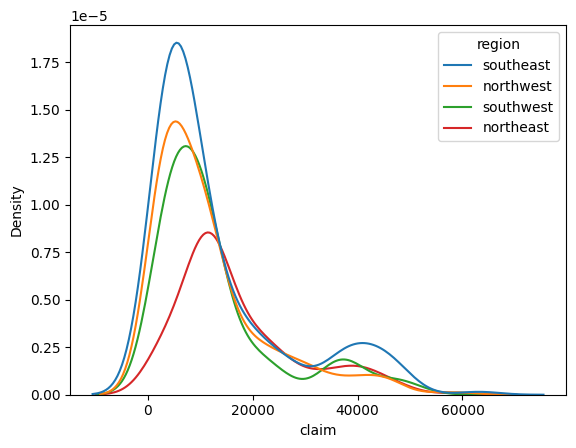

In [69]:
sns.kdeplot(insurance, x='claim', hue='region')

In [ ]:
sns.